# 🔥 Queimadas no Brasil (2015–2024): Análise Exploratória

**Disciplina:** Linguagem de Programação
**Avaliação:** G1
**Aluno(a):** Bernardo Teixeira de Oliveira Arce
**Professor:** Alexandre Neves Louzada

## 1. Introdução ao problema
Queimadas afetam biodiversidade, saúde e economia. Entender **onde**, **quando** e **sob quais condições climáticas** os focos aumentam ajuda a priorizar prevenção e combate.

**Perguntas de pesquisa**
1. Os focos de queimada aumentaram entre 2015 e 2024?
2. Existe sazonalidade ao longo do ano?
3. Quais regiões, UFs e biomas concentram mais focos?
4. Quais variáveis (temperatura, chuva, seca) mais se associam aos focos?
5. Como o nível de risco se relaciona com as demais variáveis?

## 2. Explicação da base de dados
Base **simulada** de queimadas, com **2.400 registros** (20 UFs × 120 meses, de jan/2015 a dez/2024).

| Coluna | Descrição |
|---|---|
| ano, mes, data | Período do registro |
| regiao, uf | Localização (5 regiões, 20 UFs) |
| bioma | Bioma associado ao registro |
| focos_queimada | Nº de focos no mês |
| temperatura_media | Temperatura média (°C) |
| chuva_mm | Precipitação (mm) |
| area_atingida_km2 | Área atingida (km²) |
| indice_seca | Índice de seca (0 a 1) |
| qualidade_ar | Índice de qualidade do ar (maior = melhor) |
| nivel_risco | Baixo, Médio, Alto ou Crítico |

## 3. Leitura dos dados

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="YlOrRd_r")
os.makedirs("../imagens", exist_ok=True)

df = pd.read_csv("../content/simulacao_queimadas_brasil.csv", encoding="utf-8-sig")
print(df.shape)
df.head()

(2400, 13)


,ano,mes,data,regiao,uf,bioma,focos_queimada,temperatura_media,chuva_mm,area_atingida_km2,indice_seca,qualidade_ar,nivel_risco
0,2015,1,2015-01-01,Norte,AM,Cerrado,43,29.6,40.9,29.62,0.46,65.6,Alto
1,2015,1,2015-01-01,Norte,PA,Cerrado,49,30.3,27.7,5.25,0.71,60.8,Alto
2,2015,1,2015-01-01,Norte,RO,Pampa,19,31.6,43.5,7.35,0.56,84.8,Médio
3,2015,1,2015-01-01,Norte,TO,Pampa,16,26.9,139.0,7.17,0.46,87.2,Médio
4,2015,1,2015-01-01,Nordeste,BA,Mata Atlântica,6,28.4,105.9,3.07,0.14,95.2,Baixo


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ano                2400 non-null   int64  
 1   mes                2400 non-null   int64  
 2   data               2400 non-null   object 
 3   regiao             2400 non-null   object 
 4   uf                 2400 non-null   object 
 5   bioma              2400 non-null   object 
 6   focos_queimada     2400 non-null   int64  
 7   temperatura_media  2400 non-null   float64
 8   chuva_mm           2400 non-null   float64
 9   area_atingida_km2  2400 non-null   float64
 10  indice_seca        2400 non-null   float64
 11  qualidade_ar       2400 non-null   float64
 12  nivel_risco        2400 non-null   object 
dtypes: float64(5), int64(3), object(5)
memory usage: 243.9+ KB


In [26]:
df.describe().round(2)

,ano,mes,focos_queimada,temperatura_media,chuva_mm,area_atingida_km2,indice_seca,qualidade_ar
count,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.00,2400.0
mean,2019.50,6.50,25.75,29.36,52.18,10.36,0.46,79.4
std,2.87,3.45,16.50,2.19,36.20,8.73,0.24,13.2
min,2015.00,1.00,0.00,21.60,0.00,0.00,0.00,24.8
25%,2017.00,3.75,14.00,27.90,23.10,4.11,0.29,72.0
50%,2019.50,6.50,24.00,29.40,50.35,8.08,0.44,80.8
75%,2022.00,9.25,35.00,30.80,77.60,14.03,0.62,88.8
max,2024.00,12.00,94.00,38.00,202.30,59.30,1.00,100.0


## 4. Limpeza e preparação

In [ ]:
# Valores ausentes e duplicados
print("Nulos por coluna:\n", df.isna().sum(), sep="")
print("Linhas duplicadas:", df.duplicated().sum())

# Tipos
df["data"] = pd.to_datetime(df["data"])
ordem_risco = ["Baixo", "Médio", "Alto", "Crítico"]
df["nivel_risco"] = pd.Categorical(df["nivel_risco"], categories=ordem_risco, ordered=True)

# Consistência dos intervalos
print("Mês entre 1 e 12:", df.mes.between(1, 12).all())
print("Valores negativos:", (df.select_dtypes("number") < 0).any().any())
print("Registros com 0 focos (válidos):", (df.focos_queimada == 0).sum())

Nulos por coluna:
ano                  0
mes                  0
data                 0
regiao               0
uf                   0
bioma                0
focos_queimada       0
temperatura_media    0
chuva_mm             0
area_atingida_km2    0
indice_seca          0
qualidade_ar         0
nivel_risco          0
dtype: int64
Linhas duplicadas: 0
Mês entre 1 e 12: True
Valores negativos: False
Registros com 0 focos (válidos): 63


In [ ]:
# Outliers pelo método do IQR (apenas diagnóstico: mantidos, pois são eventos plausíveis)
for col in ["focos_queimada", "area_atingida_km2", "chuva_mm", "temperatura_media"]:
    q1, q3 = df[col].quantile([.25, .75])
    lim = q3 + 1.5 * (q3 - q1)
    print(f"{col:20s} outliers acima de {lim:6.1f}: {(df[col] > lim).sum()}")

focos_queimada       outliers acima de   66.5: 49
area_atingida_km2    outliers acima de   28.9: 110
chuva_mm             outliers acima de  159.3: 6
temperatura_media    outliers acima de   35.2: 9


**Decisões de tratamento**
- A base não tem valores nulos nem linhas duplicadas.
- O arquivo tem BOM (marca de codificação UTF-8), tratado com `encoding="utf-8-sig"`.
- Outliers foram **mantidos**: picos de focos e de área atingida são justamente o fenômeno estudado.
- Observação de qualidade: o `bioma` não corresponde ao bioma real da UF (por exemplo, AM aparece como Cerrado), o que é esperado em dados simulados. A análise por bioma deve ser lida com essa ressalva.

## 5. Engenharia de atributos

In [ ]:
df["periodo_seco"] = np.where(df.mes.between(7, 10), "Seco (Jul-Out)", "Demais meses")
df["trimestre"] = df.data.dt.quarter
df["area_por_foco"] = (df.area_atingida_km2 / df.focos_queimada.replace(0, np.nan)).round(3)
df["ano_mes"] = df.data.dt.to_period("M")
df[["data", "uf", "focos_queimada", "periodo_seco", "trimestre", "area_por_foco"]].head()

,data,uf,focos_queimada,periodo_seco,trimestre,area_por_foco
0,2015-01-01,AM,43,Demais meses,1,0.689
1,2015-01-01,PA,49,Demais meses,1,0.107
2,2015-01-01,RO,19,Demais meses,1,0.387
3,2015-01-01,TO,16,Demais meses,1,0.448
4,2015-01-01,BA,6,Demais meses,1,0.512


## 6. Análise exploratória

### 6.1 Distribuições

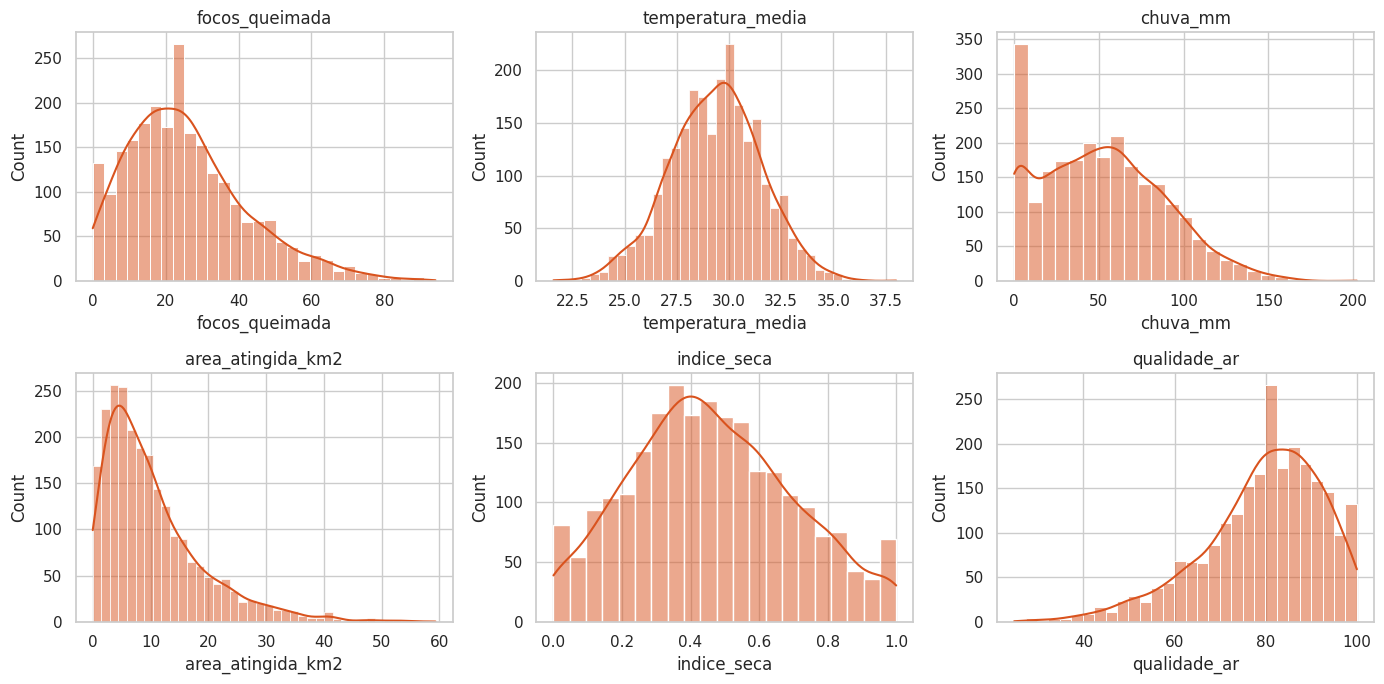

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
cols = ["focos_queimada", "temperatura_media", "chuva_mm", "area_atingida_km2", "indice_seca", "qualidade_ar"]
for ax, c in zip(axes.ravel(), cols):
    sns.histplot(df[c], kde=True, ax=ax, color="#d9531e")
    ax.set_title(c)
plt.tight_layout()
plt.savefig("../imagens/01_distribuicoes.png", dpi=130)
plt.show()

As variáveis `focos_queimada`, `area_atingida_km2` e `chuva_mm` têm assimetria à direita (muitos valores baixos e poucos extremos). `temperatura_media` é aproximadamente simétrica.

### 6.2 Evolução temporal

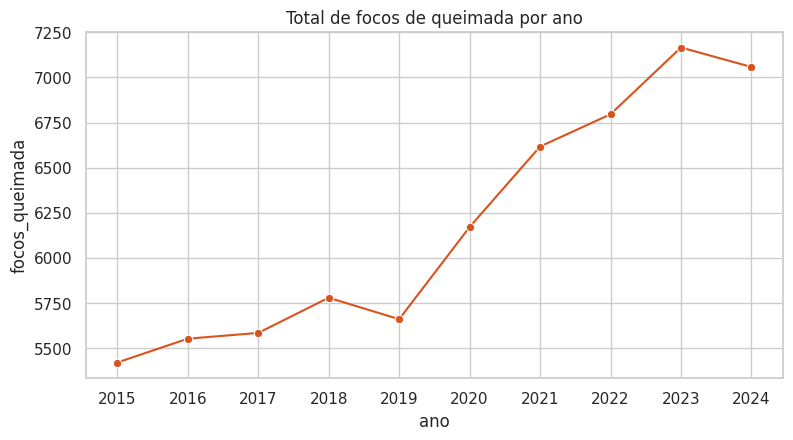

Crescimento 2015→2024: 30.2%


In [ ]:
anual = df.groupby("ano", as_index=False).focos_queimada.sum()
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(data=anual, x="ano", y="focos_queimada", marker="o", color="#d9531e", ax=ax)
ax.set_title("Total de focos de queimada por ano")
ax.set_xticks(anual.ano)
plt.savefig("../imagens/02_focos_por_ano.png", dpi=130, bbox_inches="tight")
plt.show()

cresc = (anual.focos_queimada.iloc[-1] / anual.focos_queimada.iloc[0] - 1) * 100
print(f"Crescimento 2015→2024: {cresc:.1f}%")

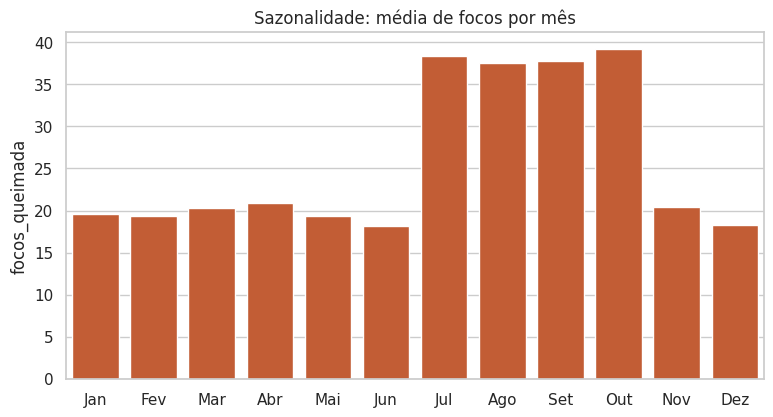

periodo_seco
Demais meses      19.5
Seco (Jul-Out)    38.2
Name: focos_queimada, dtype: float64


In [ ]:
meses = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
saz = df.groupby("mes", as_index=False).focos_queimada.mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=saz, x="mes", y="focos_queimada", color="#d9531e", ax=ax)
ax.set_xticks(range(12)); ax.set_xticklabels(meses)
ax.set_title("Sazonalidade: média de focos por mês"); ax.set_xlabel("")
plt.savefig("../imagens/03_sazonalidade.png", dpi=130, bbox_inches="tight")
plt.show()

print(df.groupby("periodo_seco").focos_queimada.mean().round(1))

### 6.3 Regiões, UFs e biomas

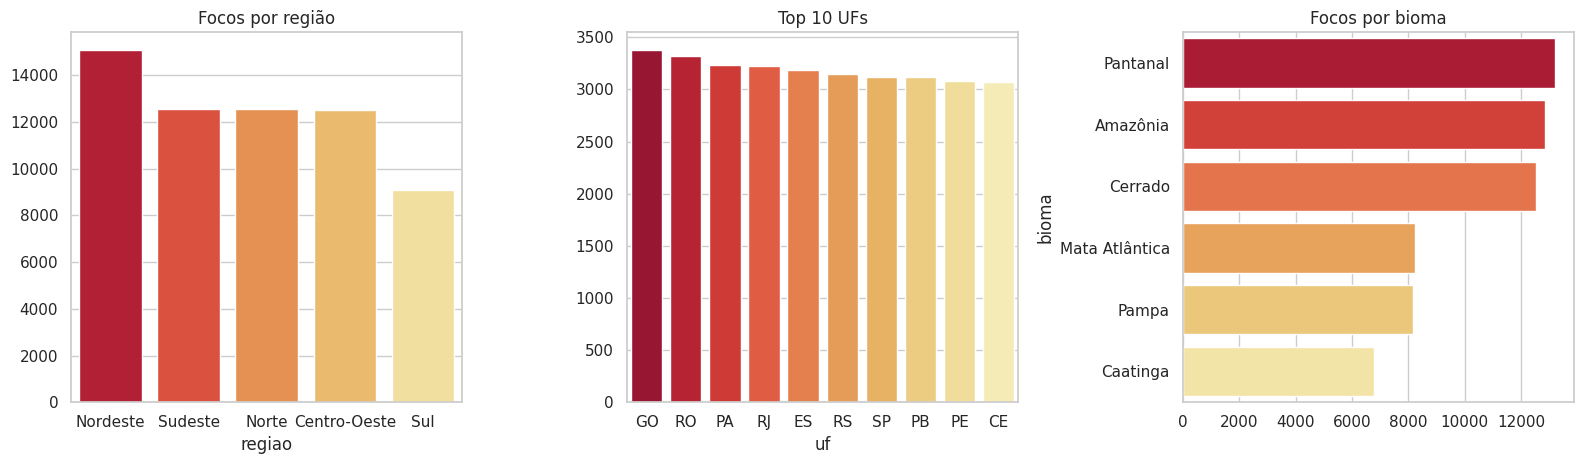

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
reg = df.groupby("regiao").focos_queimada.sum().sort_values(ascending=False)
sns.barplot(x=reg.index, y=reg.values, palette="YlOrRd_r", ax=axes[0]); axes[0].set_title("Focos por região")
uf = df.groupby("uf").focos_queimada.sum().sort_values(ascending=False).head(10)
sns.barplot(x=uf.index, y=uf.values, palette="YlOrRd_r", ax=axes[1]); axes[1].set_title("Top 10 UFs")
bio = df.groupby("bioma").focos_queimada.sum().sort_values(ascending=False)
sns.barplot(y=bio.index, x=bio.values, palette="YlOrRd_r", ax=axes[2]); axes[2].set_title("Focos por bioma")
plt.tight_layout()
plt.savefig("../imagens/04_regioes_ufs_biomas.png", dpi=130)
plt.show()

### 6.4 Nível de risco

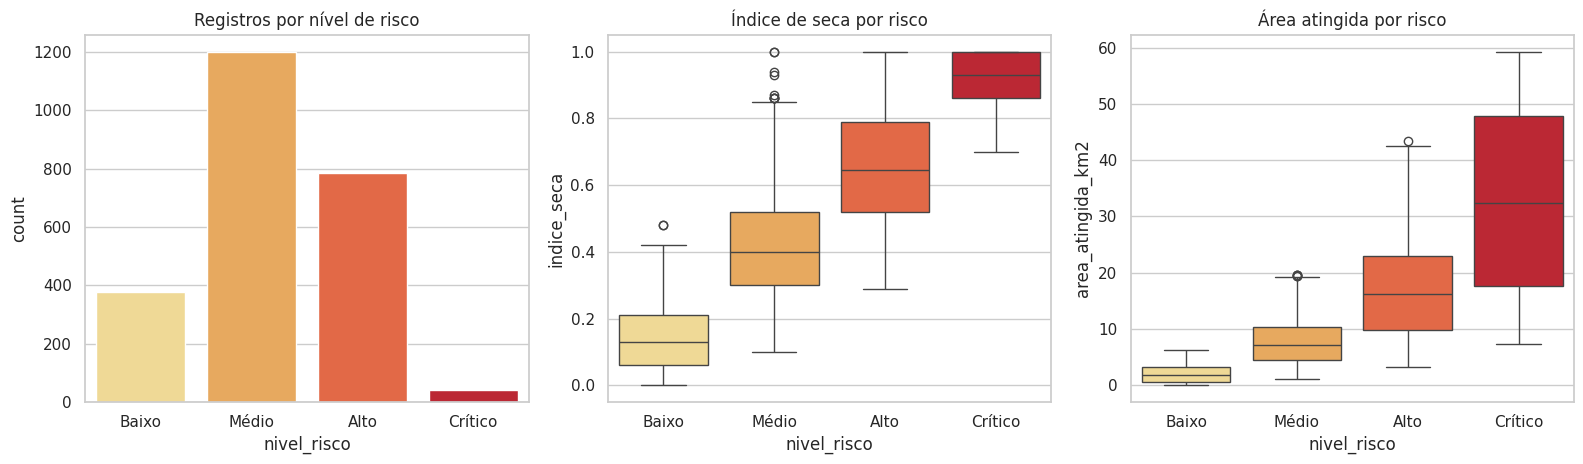

             min  max
nivel_risco          
Baixo          0    9
Médio         10   29
Alto          30   69
Crítico       70   94


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sns.countplot(data=df, x="nivel_risco", order=ordem_risco, palette="YlOrRd", ax=axes[0]); axes[0].set_title("Registros por nível de risco")
sns.boxplot(data=df, x="nivel_risco", y="indice_seca", order=ordem_risco, palette="YlOrRd", ax=axes[1]); axes[1].set_title("Índice de seca por risco")
sns.boxplot(data=df, x="nivel_risco", y="area_atingida_km2", order=ordem_risco, palette="YlOrRd", ax=axes[2]); axes[2].set_title("Área atingida por risco")
plt.tight_layout()
plt.savefig("../imagens/05_nivel_risco.png", dpi=130)
plt.show()

print(df.groupby("nivel_risco", observed=True).focos_queimada.agg(["min", "max"]))

O `nivel_risco` segue faixas de focos bem definidas (Baixo < 10, Médio 10 a 29, Alto 30 a 69, Crítico ≥ 70), o que indica que foi derivado diretamente do número de focos.

### 6.5 Correlação estatística

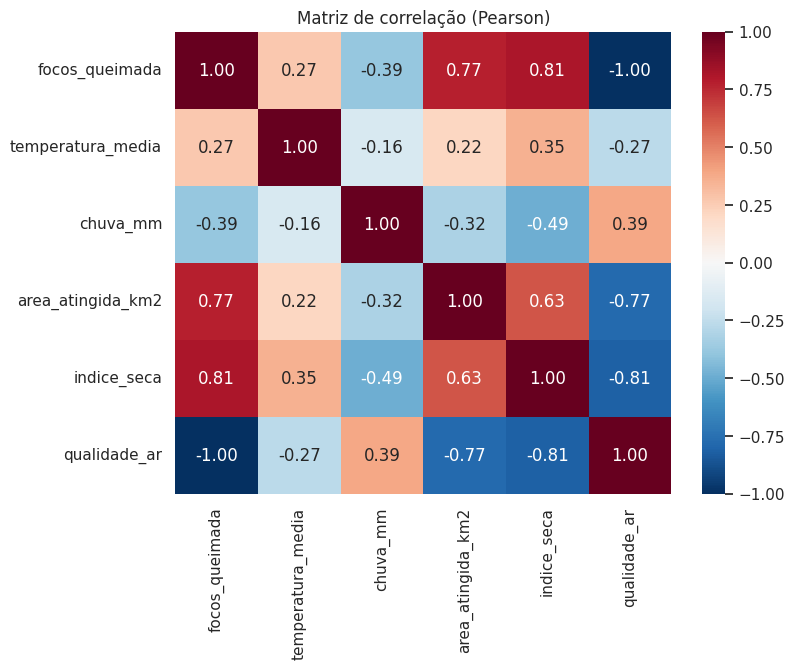

,focos_queimada
qualidade_ar,-1.000
indice_seca,0.815
area_atingida_km2,0.775
chuva_mm,-0.388
temperatura_media,0.273


In [ ]:
num = ["focos_queimada", "temperatura_media", "chuva_mm", "area_atingida_km2", "indice_seca", "qualidade_ar"]
corr = df[num].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlação (Pearson)")
plt.savefig("../imagens/06_correlacao.png", dpi=130, bbox_inches="tight")
plt.show()
corr["focos_queimada"].drop("focos_queimada").sort_values(key=abs, ascending=False).round(3)

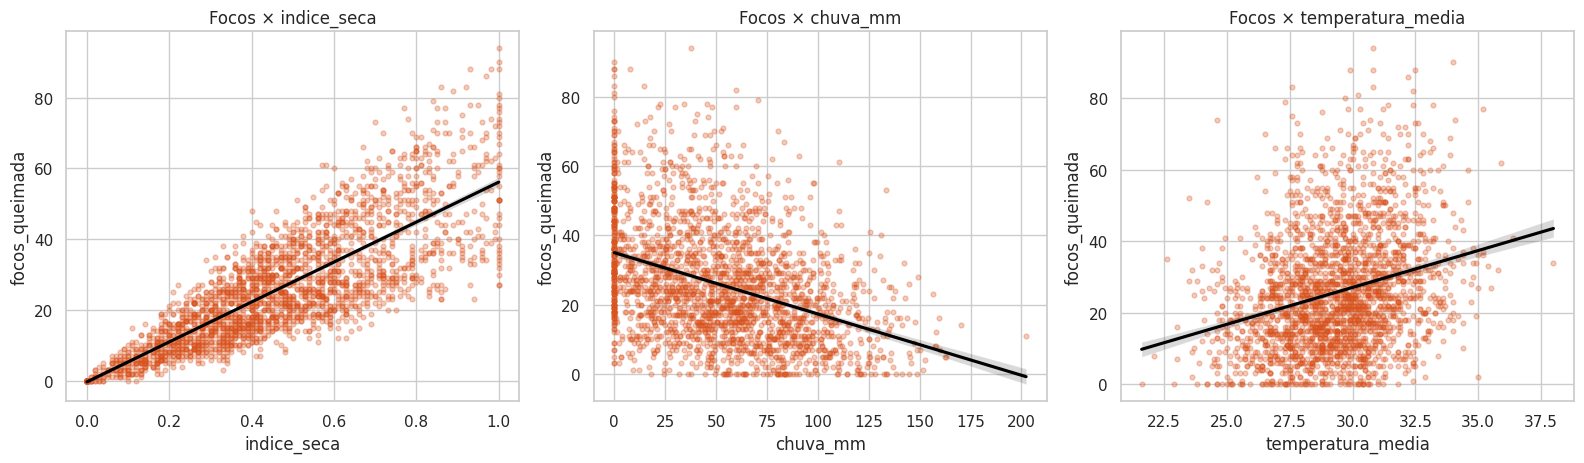

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, c in zip(axes, ["indice_seca", "chuva_mm", "temperatura_media"]):
    sns.regplot(data=df, x=c, y="focos_queimada", scatter_kws={"alpha": .3, "s": 12}, line_kws={"color": "black"}, color="#d9531e", ax=ax)
    ax.set_title(f"Focos × {c}")
plt.tight_layout()
plt.savefig("../imagens/07_dispersao.png", dpi=130)
plt.show()

## 7. KPIs

In [ ]:
kpis = {
    "Total de focos": int(df.focos_queimada.sum()),
    "Área total atingida (km²)": round(df.area_atingida_km2.sum(), 1),
    "Média de focos por UF-mês": round(df.focos_queimada.mean(), 1),
    "Qualidade média do ar": round(df.qualidade_ar.mean(), 1),
    "% registros Alto/Crítico": round(df.nivel_risco.isin(["Alto", "Crítico"]).mean() * 100, 1),
    "Mês de pico (média de focos)": meses[int(saz.loc[saz.focos_queimada.idxmax(), "mes"]) - 1],
    "UF com mais focos": df.groupby("uf").focos_queimada.sum().idxmax(),
    "Crescimento 2015→2024 (%)": round(cresc, 1),
}
pd.Series(kpis, name="valor").to_frame()

,valor
Total de focos,61803
Área total atingida (km²),24874.6
Média de focos por UF-mês,25.8
Qualidade média do ar,79.4
% registros Alto/Crítico,34.4
Mês de pico (média de focos),Out
UF com mais focos,GO
Crescimento 2015→2024 (%),30.2


## 8. Gráficos adicionais: mapa de calor mês × ano

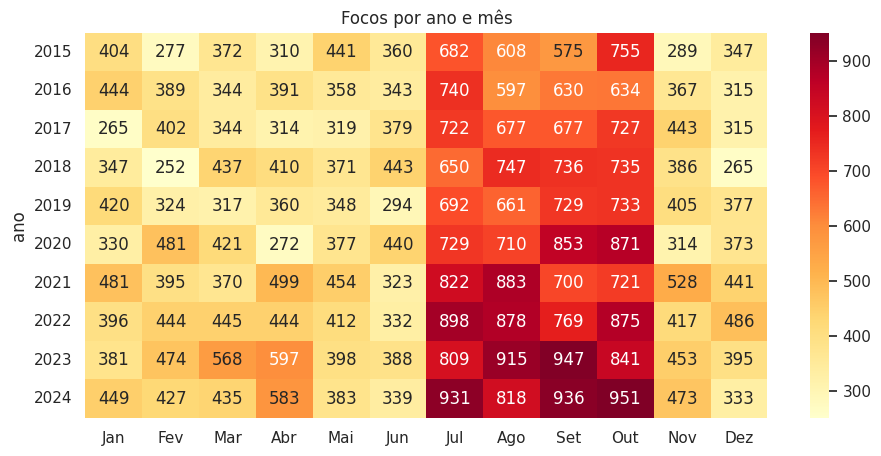

In [ ]:
pivot = df.pivot_table(index="ano", columns="mes", values="focos_queimada", aggfunc="sum")
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt="d", ax=ax, xticklabels=meses)
ax.set_title("Focos por ano e mês"); ax.set_xlabel("")
plt.savefig("../imagens/08_mapa_calor.png", dpi=130, bbox_inches="tight")
plt.show()

## 9. Interpretação dos resultados
- **Tendência:** os focos cresceram ao longo da década, com salto a partir de 2020.
- **Sazonalidade:** de julho a outubro a média de focos é cerca do dobro dos demais meses, coerente com o período seco.
- **Geografia:** o Nordeste concentra o maior volume por ter mais UFs na amostra (5 UFs, contra 3 a 4 nas outras regiões); a diferença entre UFs individuais é pequena.
- **Clima:** o índice de seca tem a correlação positiva mais forte com os focos (r ≈ 0,81), a chuva tem correlação negativa moderada (r ≈ −0,39) e a temperatura, correlação fraca (r ≈ 0,27).
- **Qualidade do ar:** correlação praticamente perfeita e negativa com os focos (r ≈ −1,00). Em dados reais isso seria improvável; aqui indica que a variável foi gerada a partir dos focos.
- **Correlação não é causalidade:** os resultados descrevem associações em uma base simulada.

## 10. Conclusão
O projeto mostrou que os focos de queimada na base crescem ao longo do tempo, concentram-se de julho a outubro e estão mais associados à seca e à baixa precipitação do que à temperatura. Para a gestão, isso sugere reforçar a prevenção no período seco e usar o índice de seca como indicador antecipado de risco.

**Limitações:** base simulada, biomas inconsistentes com as UFs e variáveis derivadas entre si (`nivel_risco` e `qualidade_ar`). **Próximos passos:** testar com dados reais (INPE/BDQueimadas), modelar a previsão de focos e incluir mapas por município.